SOIL MOISTURE STUFF

In [1]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

In [2]:
ds = xr.open_dataset('POWER_Regional_Daily_20240101_20241231.nc')
ds

<xarray.Dataset>
Dimensions:  (time: 366, lat: 13, lon: 8)
Coordinates:
  * time     (time) datetime64[ns] 2024-01-01 2024-01-02 ... 2024-12-31
  * lat      (lat) float64 5.0 5.5 6.0 6.5 7.0 7.5 ... 9.0 9.5 10.0 10.5 11.0
  * lon      (lon) float64 -3.125 -2.5 -1.875 -1.25 -0.625 -5.92e-13 0.625 1.25
Data variables:
    T2M      (time, lat, lon) float64 ...
Attributes: (12/22)
    acknowledgement:           The Prediction of Worldwide Energy Resources (...
    comment:                   POWER data version 10.0.0 uses the source data...
    conventions:               CF-1.8, ACDD-1.3
    creator_email:             bradley.macpherson@nasa.gov
    creator_name:              Bradley Macpherson
    derived_from:              The data products are derived from data partne...
    ...                        ...
    publisher_name:            Paul Stackhouse
    references:                https://power.larc.nasa.gov
    source:                    Prediction Of Worldwide Energy Resource (POWER)
    standard_name_vocabulary:  CF Standard Name Table v72
    summary:                   The POWER project provides solar and meteorolo...
    version:                   POWER Version 10.0.0

In [3]:
temp = ds.T2M
temp

<xarray.DataArray 'T2M' (time: 366, lat: 13, lon: 8)>
[38064 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2024-01-01 2024-01-02 ... 2024-12-31
  * lat      (lat) float64 5.0 5.5 6.0 6.5 7.0 7.5 ... 9.0 9.5 10.0 10.5 11.0
  * lon      (lon) float64 -3.125 -2.5 -1.875 -1.25 -0.625 -5.92e-13 0.625 1.25
Attributes:
    base:                float32
    cell_methods:        time: mean
    definition:          The average air (dry bulb) temperature at 2 meters a...
    long_name:           Temperature at 2 Meters
    significant_digits:  2
    standard_name:       Temperature_at_2_Meters
    status:              official
    units:               C
    valid_max:           80.0
    valid_min:           -125.0

In [5]:
monthly =  temp.groupby('time.month').mean('time')
season = temp.groupby('time.season').mean('time')

(array([  8.,  30.,  41., 268., 405., 235., 139.,  45.,  48.,  29.]),
 array([20.26451613, 21.65606452, 23.0476129 , 24.43916129, 25.83070968,
        27.22225806, 28.61380645, 30.00535484, 31.39690323, 32.78845161,
        34.18      ]),
 <BarContainer object of 10 artists>)

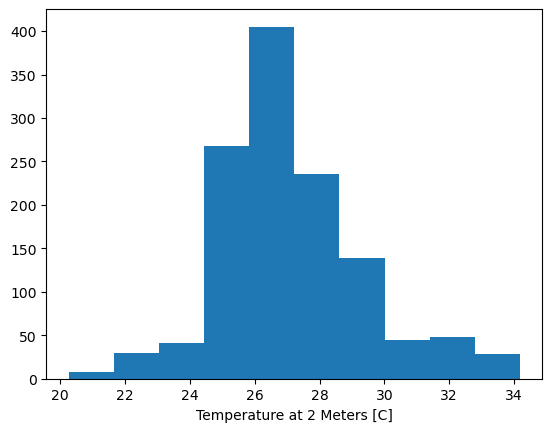

In [5]:
monthly.plot()

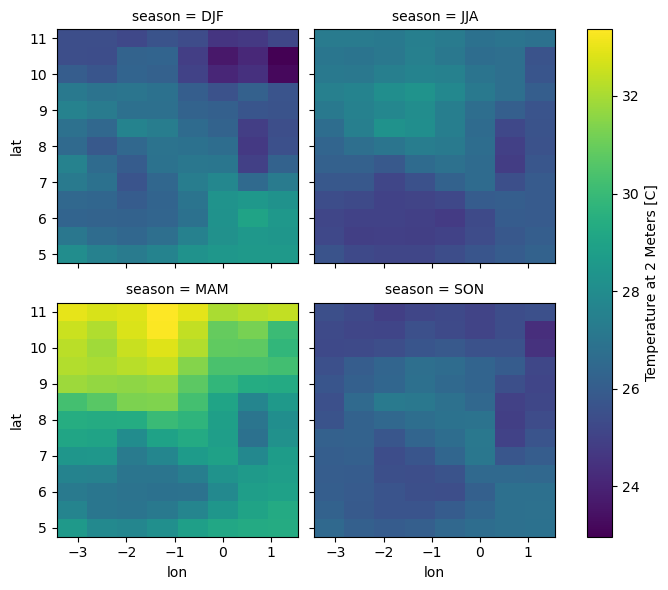

In [6]:
season.plot(col_wrap=2,col='season')

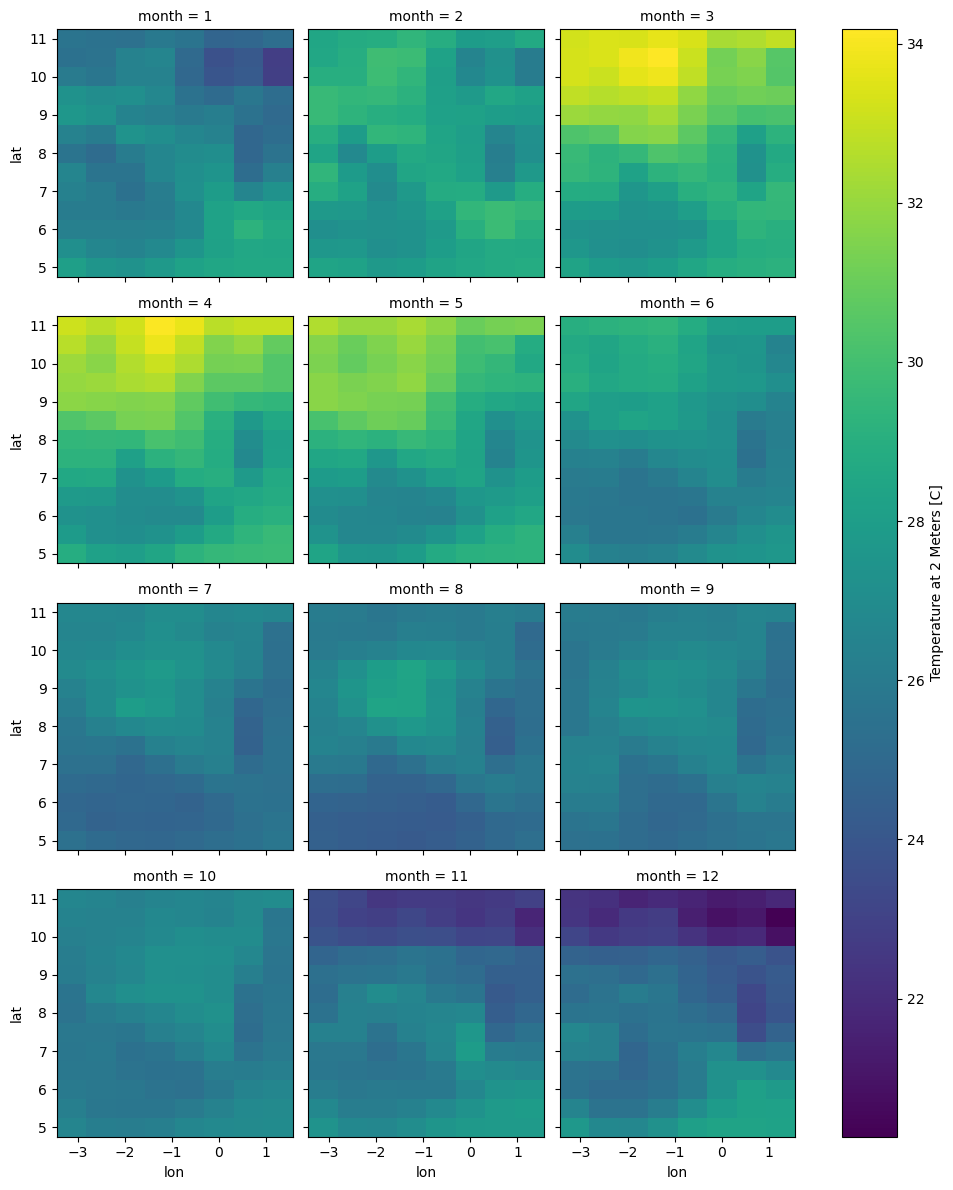

In [6]:
monthly.plot(col_wrap=3, col='month')

In [7]:
month_names = ['Jan','Feb','Mar','Apr','May','June','July','Aug','Sept','Oct','Nov','Dec']

In [7]:
season_names=['DJF','JJA','MAM','SON']

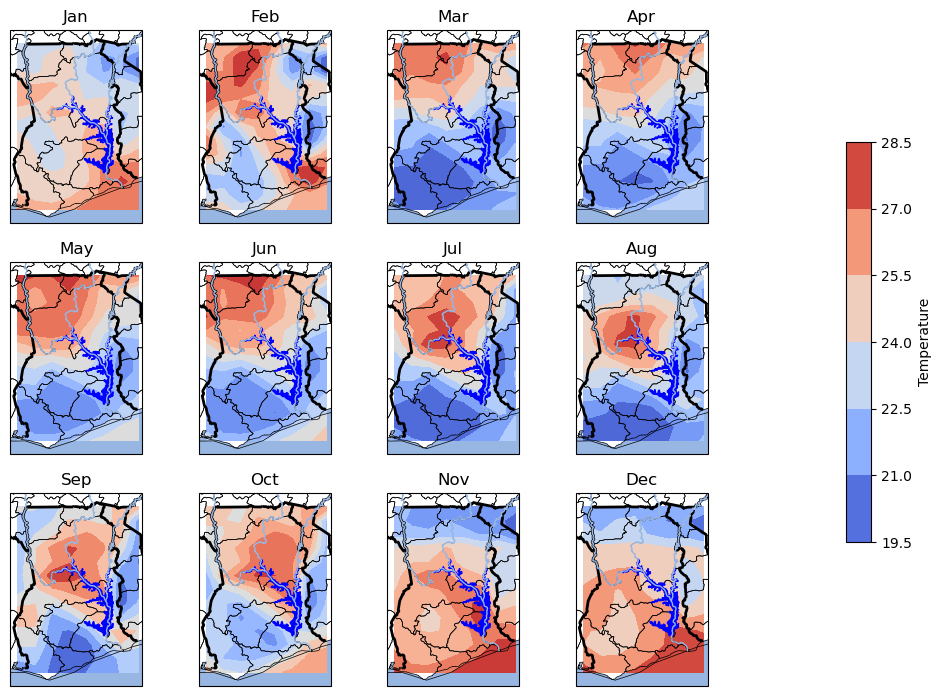

In [17]:
#alternatively 
fig,ax=plt.subplots(3,4,figsize=(10,8),  
                    subplot_kw={'projection': ccrs.PlateCarree()}) 
ax=ax.flatten() 
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] 
for i in range(12): 
    ax[i].add_feature(cfeature.COASTLINE.with_scale('110m'),linewidth=0.5) 
    ax[i].add_feature(cfeature.BORDERS,linewidth=2) 
    ax[i].add_feature(cfeature.STATES, linewidth=0.5) 
    ax[i].add_feature(cfeature.OCEAN) 
    ax[i].add_feature(cfeature.LAKES, color='blue') 
    ax[i].add_feature(cfeature.RIVERS) 
    ax[i].set_extent([-3.4,1.4,4.5,11.5])
    ax[i].set_title(month_names[i]) 
    cb=ax[i].contourf(monthly[i].lon, monthly[i].lat, monthly[i],cmap='coolwarm',transform=ccrs.PlateCarree())
color_bar=fig.add_axes([1.0,0.29,0.025,0.5]) 
fig.colorbar(cb,cax=color_bar,label='Temperature') 
fig.subplots_adjust(wspace=-0.1, top=0.93);

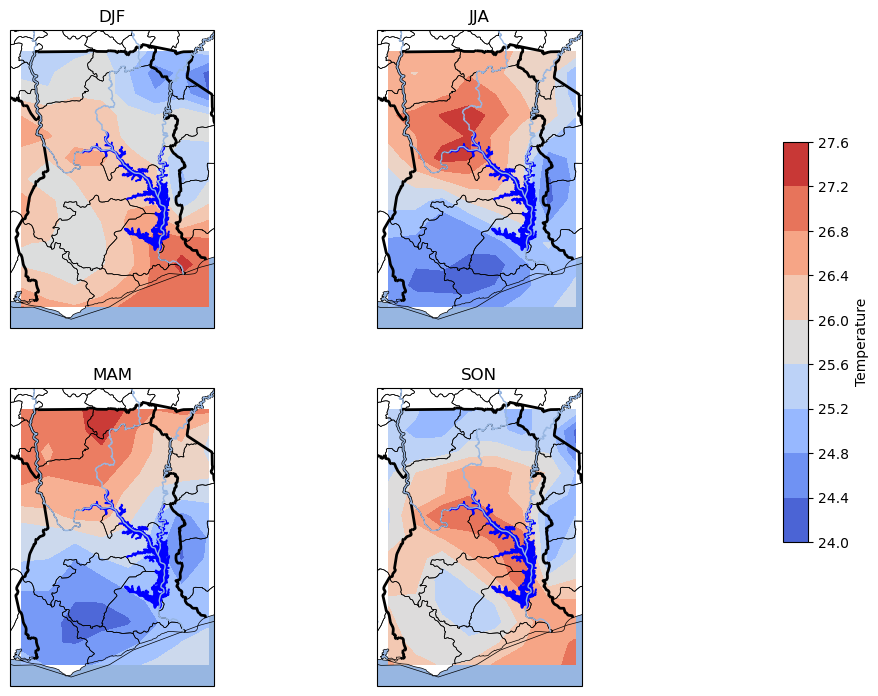

In [8]:
fig,ax=plt.subplots(2,2,figsize=(10,8),  
                    subplot_kw={'projection': ccrs.PlateCarree()}) 
ax=ax.flatten() 
#month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] 
for i in range(4): 
    ax[i].add_feature(cfeature.COASTLINE.with_scale('110m'),linewidth=0.5) 
    ax[i].add_feature(cfeature.BORDERS,linewidth=2) 
    ax[i].add_feature(cfeature.STATES, linewidth=0.5) 
    ax[i].add_feature(cfeature.OCEAN) 
    ax[i].add_feature(cfeature.LAKES, color='blue') 
    ax[i].add_feature(cfeature.RIVERS) 
    ax[i].set_extent([-3.4,1.4,4.5,11.5])
    ax[i].set_title(season_names[i]) 
    cb=ax[i].contourf(season[i].lon, season[i].lat, season[i],cmap='coolwarm',transform=ccrs.PlateCarree())
color_bar=fig.add_axes([1.0,0.29,0.025,0.5]) 
fig.colorbar(cb,cax=color_bar,label='Temperature') 
fig.subplots_adjust(wspace=-0.1, top=0.93);

In [11]:
df = xr.open_dataset('Ghana_ERA5_dTn_1960_2024.nc')
df = df.mn2t

In [24]:
df

<xarray.DataArray 'mn2t' (time: 23741, latitude: 31, longitude: 21)>
array([[[15.541738, 15.852133, ..., 16.434244, 16.246708],
        [16.012368, 15.983116, ..., 17.096311, 16.920475],
        ...,
        [27.137491, 27.147241, ..., 26.906726, 26.926552],
        [27.12774 , 27.090363, ..., 26.916802, 26.932403]],

       [[15.167965, 15.212818, ..., 15.499811, 15.386704],
        [15.624944, 15.505661, ..., 16.078022, 15.976616],
        ...,
        [26.845622, 26.81247 , ..., 26.720489, 26.710739],
        [26.771518, 26.800769, ..., 26.763717, 26.752016]],

       ...,

       [[23.576801, 23.915262, ..., 26.386045, 26.093891],
        [24.351624, 24.53017 , ..., 26.497456, 26.294575],
        ...,
        [28.450825, 28.402241, ..., 28.3491  , 28.299622],
        [28.469461, 28.423645, ..., 28.316385, 28.26593 ]],

       [[24.738281, 24.987141, ..., 27.657389, 27.318521],
        [25.38802 , 25.464598, ..., 27.708414, 27.45524 ],
        ...,
        [28.54842 , 28.5284  , ..., 28.31665 , 28.278238],
        [28.531574, 28.539143, ..., 28.306885, 28.268879]]])
Coordinates:
  * time       (time) datetime64[ns] 1960-01-01T06:00:00 ... 2024-12-31T11:00:00
  * longitude  (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude   (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
Attributes:
    long_name:  Minimum temperature at 2 metres since previous post-processing
    units:      K

In [13]:
mon = df.groupby('time.month').mean('time')
mon

<xarray.DataArray 'mn2t' (month: 12, latitude: 31, longitude: 21)>
array([[[21.69266261, 21.82046267, 21.3629602 , ..., 22.53099045,
         22.77344417, 22.62454104],
        [22.12422697, 22.1574796 , 21.64592465, ..., 23.20336057,
         23.11681179, 22.96971642],
        [22.37724624, 22.41168742, 22.22394136, ..., 23.32541994,
         23.23765298, 23.21339734],
        ...,
        [26.53044552, 26.50366304, 26.06734753, ..., 26.93694421,
         26.94257137, 26.96246624],
        [26.74284138, 26.71947852, 26.73008923, ..., 26.93164818,
         26.93868065, 26.95598998],
        [26.76531763, 26.75215049, 26.76082793, ..., 26.92025244,
         26.91792888, 26.93324267]],

       [[24.08649061, 24.17281313, 23.69155663, ..., 24.75450948,
         25.00780975, 24.88923128],
        [24.4338911 , 24.4601761 , 23.94629081, ..., 25.34882364,
         25.2781138 , 25.15893875],
        [24.63868376, 24.66628615, 24.50381669, ..., 25.38570215,
         25.3138107 , 25.32245508],
...
        [26.02737471, 26.01073968, 25.6254075 , ..., 26.72921372,
         26.74118342, 26.76350917],
        [26.19530284, 26.18386772, 26.21829697, ..., 26.63510884,
         26.64910831, 26.67541108],
        [26.10376825, 26.1146406 , 26.14718899, ..., 26.53479209,
         26.54097123, 26.56528981]],

       [[22.02425241, 22.22218409, 21.79940755, ..., 23.08546647,
         23.30659159, 23.11140079],
        [22.4762978 , 22.54316345, 22.03252236, ..., 23.6992013 ,
         23.56248776, 23.37086733],
        [22.67252432, 22.74046655, 22.56233744, ..., 23.75480864,
         23.62059021, 23.6022372 ],
        ...,
        [26.51682797, 26.49508866, 26.04764412, ..., 27.11212932,
         27.1173    , 27.13251344],
        [26.70007187, 26.68308805, 26.71019356, ..., 27.05689865,
         27.06438749, 27.08689094],
        [26.62263067, 26.62206332, 26.64714525, ..., 26.98986684,
         26.99271035, 27.01320031]]])
Coordinates:
  * longitude  (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude   (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:  Minimum temperature at 2 metres since previous post-processing
    units:      K

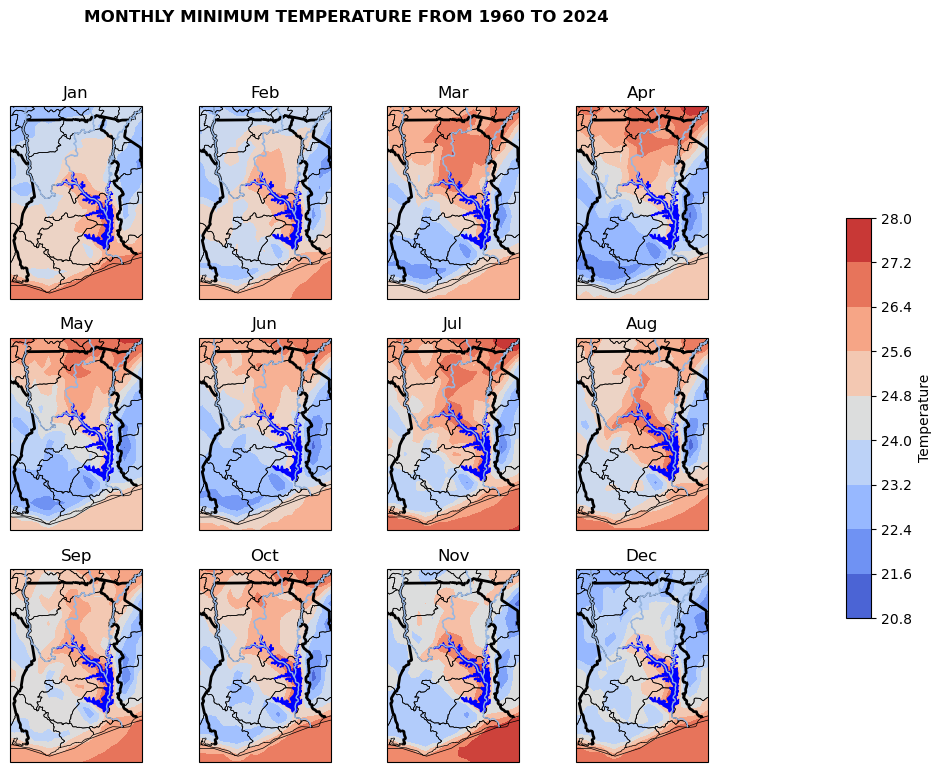

In [25]:
fig,ax=plt.subplots(3,4,figsize=(10,8),  
                    subplot_kw={'projection': ccrs.PlateCarree()}) 
ax=ax.flatten() 
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] 
for i in range(12): 
    ax[i].add_feature(cfeature.COASTLINE.with_scale('110m'),linewidth=0.5) 
    ax[i].add_feature(cfeature.BORDERS,linewidth=2) 
    ax[i].add_feature(cfeature.STATES, linewidth=0.5) 
    ax[i].add_feature(cfeature.OCEAN) 
    ax[i].add_feature(cfeature.LAKES, color='blue') 
    ax[i].add_feature(cfeature.RIVERS) 
    ax[i].set_extent([-3.4,1.4,4.5,11.5])
    ax[i].set_title(month_names[i]) 
    cb=ax[i].contourf(mon[i].longitude, mon[i].latitude, mon[i],cmap='coolwarm',transform=ccrs.PlateCarree())
color_bar=fig.add_axes([1.0,0.29,0.025,0.5]) 
fig.colorbar(cb,cax=color_bar,label='Temperature') 
plt.suptitle('MONTHLY MINIMUM TEMPERATURE FROM 1960 TO 2024',y=1.05,fontweight='bold')
fig.subplots_adjust(wspace=-0.1, top=0.93);

In [29]:
annual = df.sel(time=slice('1991','2020'))
annual                

<xarray.DataArray 'mn2t' (time: 10958, latitude: 31, longitude: 21)>
array([[[21.909962, 22.012827, ..., 21.915741, 21.734913],
        [22.202118, 22.426075, ..., 22.493622, 22.297901],
        ...,
        [27.169565, 27.314423, ..., 27.393116, 27.428598],
        [27.329559, 27.378143, ..., 27.508188, 27.541065]],

       [[21.8892  , 21.985718, ..., 22.119343, 21.906208],
        [22.230347, 22.468302, ..., 22.669636, 22.44755 ],
        ...,
        [27.226603, 27.163208, ..., 27.853718, 27.831745],
        [27.345255, 27.405964, ..., 27.984985, 27.96106 ]],

       ...,

       [[24.157761, 24.118698, ..., 25.920374, 25.719934],
        [24.444544, 23.951542, ..., 26.356165, 26.179813],
        ...,
        [27.524216, 27.475388, ..., 28.089808, 28.1318  ],
        [27.6012  , 27.600712, ..., 28.082321, 28.123417]],

       [[24.652815, 24.798567, ..., 26.298567, 26.126448],
        [25.051741, 24.854719, ..., 26.747379, 26.603662],
        ...,
        [27.545557, 27.541651, ..., 28.070377, 28.096338],
        [27.647202, 27.630436, ..., 27.98208 , 28.006168]]])
Coordinates:
  * time       (time) datetime64[ns] 1991-01-01T11:00:00 ... 2020-12-31T11:00:00
  * longitude  (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude   (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
Attributes:
    long_name:  Minimum temperature at 2 metres since previous post-processing
    units:      K

In [34]:
sea= df.groupby('time.season').mean('time')
sea

<xarray.DataArray 'mn2t' (season: 4, latitude: 31, longitude: 21)>
array([[[22.55621793, 22.69511941, 22.24210665, ..., 23.41777423,
         23.65629818, 23.5009915 ],
        [22.96846081, 23.0110777 , 22.49910689, ..., 24.04555879,
         23.94673829, 23.79309189],
        [23.18686882, 23.23067614, 23.05414918, ..., 24.11811627,
         24.01936458, 24.00743951],
        ...,
        [26.59376721, 26.57205834, 26.16553755, ..., 27.12017056,
         27.13064673, 27.15391278],
        [26.79666723, 26.77853917, 26.79533673, ..., 27.09418076,
         27.10623113, 27.12877043],
        [26.79326058, 26.78604548, 26.80102469, ..., 27.06206079,
         27.06638531, 27.08698442]],

       [[24.86680782, 25.00182235, 25.15953207, ..., 25.55273305,
         25.60733159, 25.47698414],
        [24.74970143, 24.90168201, 25.01550001, ..., 25.58016167,
         25.56451598, 25.42865077],
        [24.62289516, 24.77130397, 24.87627474, ..., 25.48366875,
         25.47343602, 25.51104184],
...
        [26.75273478, 26.7349868 , 26.42229431, ..., 27.37672599,
         27.3908204 , 27.41530234],
        [26.98096453, 26.9668741 , 26.98484625, ..., 27.34288522,
         27.35840994, 27.38384826],
        [26.98775565, 26.98580473, 27.00221982, ..., 27.31079393,
         27.31992183, 27.34365626]],

       [[24.32288304, 24.58271777, 24.59944504, ..., 25.07919419,
         25.189686  , 24.98608478],
        [24.38691591, 24.58435669, 24.51204356, ..., 25.21189364,
         25.09947286, 24.89207556],
        [24.3124777 , 24.50585923, 24.55280413, ..., 25.0945506 ,
         24.99270817, 25.05640207],
        ...,
        [25.10053152, 25.09432775, 24.80310471, ..., 25.68983001,
         25.71051462, 25.74401254],
        [25.26823329, 25.26451058, 25.28443394, ..., 25.64756386,
         25.66950138, 25.69854714],
        [25.2735983 , 25.274655  , 25.29316765, ..., 25.6074945 ,
         25.6165847 , 25.64373598]]])
Coordinates:
  * longitude  (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude   (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
  * season     (season) object 'DJF' 'JJA' 'MAM' 'SON'
Attributes:
    long_name:  Minimum temperature at 2 metres since previous post-processing
    units:      K

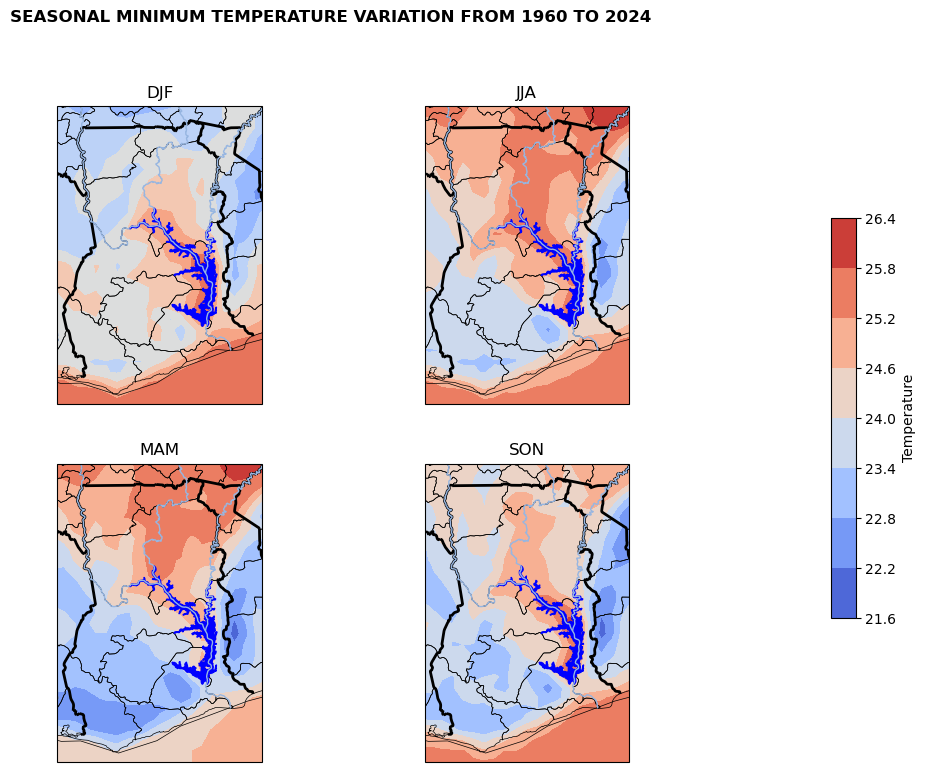

In [36]:
fig,ax=plt.subplots(2,2,figsize=(10,8),  
                    subplot_kw={'projection': ccrs.PlateCarree()}) 
ax=ax.flatten() 
#month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] 
for i in range(4): 
    ax[i].add_feature(cfeature.COASTLINE.with_scale('110m'),linewidth=0.5) 
    ax[i].add_feature(cfeature.BORDERS,linewidth=2) 
    ax[i].add_feature(cfeature.STATES, linewidth=0.5) 
    ax[i].add_feature(cfeature.OCEAN) 
    ax[i].add_feature(cfeature.LAKES, color='blue') 
    ax[i].add_feature(cfeature.RIVERS) 
    ax[i].set_extent([-3.4,1.4,4.5,11.5])
    ax[i].set_title(season_names[i]) 
    cb=ax[i].contourf(sea[i].longitude, sea[i].latitude, sea[i],cmap='coolwarm',transform=ccrs.PlateCarree())
color_bar=fig.add_axes([1.0,0.29,0.025,0.5]) 
fig.colorbar(cb,cax=color_bar,label='Temperature') 
plt.suptitle('SEASONAL MINIMUM TEMPERATURE VARIATION FROM 1960 TO 2024',y=1.05,fontweight='bold')
fig.subplots_adjust(wspace=-0.1, top=0.93);

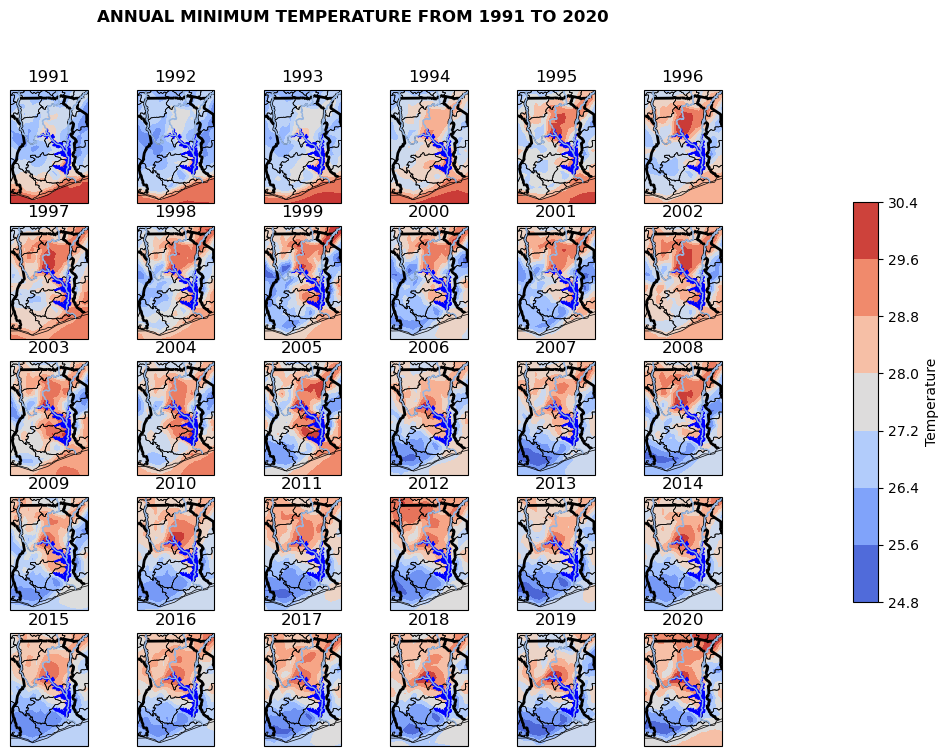

In [37]:
fig,ax=plt.subplots(5,6,figsize=(10,8),  
                    subplot_kw={'projection': ccrs.PlateCarree()}) 
ax=ax.flatten() 
year_names = [str(year) for year in range(1991, 2021)]
for i in range(30): 
    ax[i].add_feature(cfeature.COASTLINE.with_scale('110m'),linewidth=0.5) 
    ax[i].add_feature(cfeature.BORDERS,linewidth=2) 
    ax[i].add_feature(cfeature.STATES, linewidth=0.5) 
    ax[i].add_feature(cfeature.OCEAN) 
    ax[i].add_feature(cfeature.LAKES, color='blue') 
    ax[i].add_feature(cfeature.RIVERS) 
    ax[i].set_extent([-3.4,1.4,4.5,11.5])
    ax[i].set_title(year_names[i]) 
    cb=ax[i].contourf(annual[i].longitude, annual[i].latitude, annual[i],cmap='coolwarm',transform=ccrs.PlateCarree())
color_bar=fig.add_axes([1.0,0.29,0.025,0.5]) 
fig.colorbar(cb,cax=color_bar,label='Temperature') 
plt.suptitle('ANNUAL MINIMUM TEMPERATURE FROM 1991 TO 2020',y=1.03,fontweight='bold')
fig.subplots_adjust(wspace=-0.1, top=0.93);

In [41]:
dss = xr.open_mfdataset('C:/Users/ampon/Desktop/PYTHON/TEMP_1994_2024/*.nc')
dss = dss.t2m
dss                      

<xarray.DataArray 't2m' (valid_time: 271752, latitude: 31, longitude: 21)>
dask.array<concatenate, shape=(271752, 31, 21), dtype=float32, chunksize=(17544, 31, 21), chunktype=numpy.ndarray>
Coordinates:
    number      int64 0
  * valid_time  (valid_time) datetime64[ns] 1994-01-01 ... 2024-12-31T23:00:00
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
    expver      (valid_time) object dask.array<chunksize=(17520,), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      651
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [42]:
month= dss.groupby('valid_time.month').mean('valid_time')
month

<xarray.DataArray 't2m' (month: 12, latitude: 31, longitude: 21)>
dask.array<stack, shape=(12, 31, 21), dtype=float32, chunksize=(1, 31, 21), chunktype=numpy.ndarray>
Coordinates:
    number     int64 0
  * latitude   (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
  * longitude  (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * month      (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      651
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

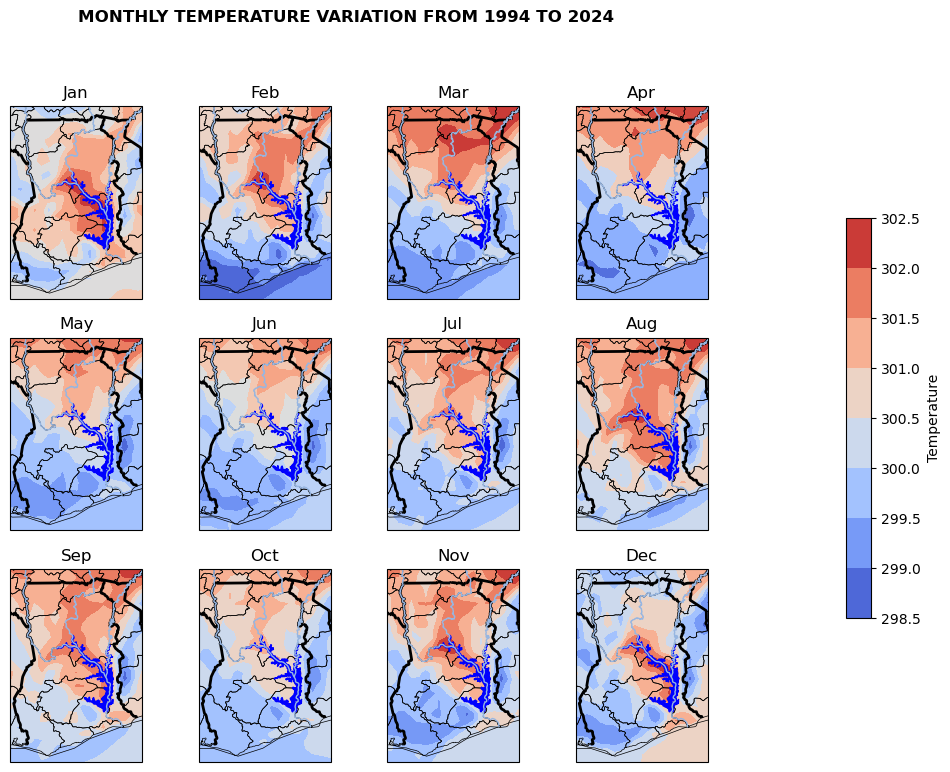

In [43]:
fig,ax=plt.subplots(3,4,figsize=(10,8),  
                    subplot_kw={'projection': ccrs.PlateCarree()}) 
ax=ax.flatten() 
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] 
for i in range(12): 
    ax[i].add_feature(cfeature.COASTLINE.with_scale('110m'),linewidth=0.5) 
    ax[i].add_feature(cfeature.BORDERS,linewidth=2) 
    ax[i].add_feature(cfeature.STATES, linewidth=0.5) 
    ax[i].add_feature(cfeature.OCEAN) 
    ax[i].add_feature(cfeature.LAKES, color='blue') 
    ax[i].add_feature(cfeature.RIVERS) 
    ax[i].set_extent([-3.4,1.4,4.5,11.5])
    ax[i].set_title(month_names[i]) 
    cb=ax[i].contourf(month[i].longitude, month[i].latitude, month[i],cmap='coolwarm',transform=ccrs.PlateCarree())
color_bar=fig.add_axes([1.0,0.29,0.025,0.5]) 
fig.colorbar(cb,cax=color_bar,label='Temperature') 
plt.suptitle('MONTHLY TEMPERATURE VARIATION FROM 1994 TO 2024',y=1.05,fontweight='bold')
fig.subplots_adjust(wspace=-0.1, top=0.93);

In [44]:
ann = dss.groupby('valid_time.year').mean('valid_time')
ann

<xarray.DataArray 't2m' (year: 31, latitude: 31, longitude: 21)>
dask.array<stack, shape=(31, 31, 21), dtype=float32, chunksize=(1, 31, 21), chunktype=numpy.ndarray>
Coordinates:
    number     int64 0
  * latitude   (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
  * longitude  (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * year       (year) int64 1994 1995 1996 1997 1998 ... 2021 2022 2023 2024
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      651
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

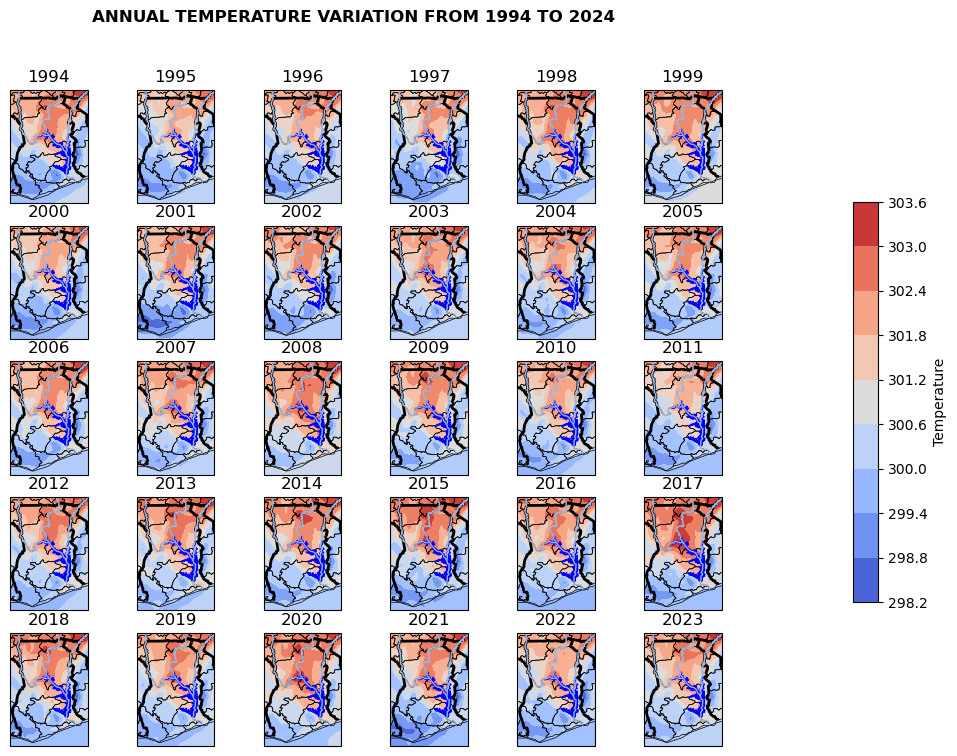

In [45]:
fig,ax=plt.subplots(5,6,figsize=(10,8),  
                    subplot_kw={'projection': ccrs.PlateCarree()}) 
ax=ax.flatten() 
year_names = [str(year) for year in range(1994, 2025)]
for i in range(30): 
    ax[i].add_feature(cfeature.COASTLINE.with_scale('110m'),linewidth=0.5) 
    ax[i].add_feature(cfeature.BORDERS,linewidth=2) 
    ax[i].add_feature(cfeature.STATES, linewidth=0.5) 
    ax[i].add_feature(cfeature.OCEAN) 
    ax[i].add_feature(cfeature.LAKES, color='blue') 
    ax[i].add_feature(cfeature.RIVERS) 
    ax[i].set_extent([-3.4,1.4,4.5,11.5])
    ax[i].set_title(year_names[i]) 
    cb=ax[i].contourf(ann[i].longitude, ann[i].latitude, ann[i],cmap='coolwarm',transform=ccrs.PlateCarree())
color_bar=fig.add_axes([1.0,0.29,0.025,0.5]) 
fig.colorbar(cb,cax=color_bar,label='Temperature') 
plt.suptitle('ANNUAL TEMPERATURE VARIATION FROM 1994 TO 2024',y=1.03,fontweight='bold')
fig.subplots_adjust(wspace=-0.1, top=0.93);

In [4]:
data=xr.open_dataset('SOIL_MOISTURE.nc')
data

<xarray.Dataset>
Dimensions:    (longitude: 33, latitude: 37, time: 504)
Coordinates:
  * longitude  (longitude) float32 -5.0 -4.75 -4.5 -4.25 ... 2.25 2.5 2.75 3.0
  * latitude   (latitude) float32 12.0 11.75 11.5 11.25 ... 3.75 3.5 3.25 3.0
  * time       (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2021-12-01
Data variables:
    stl1       (time, latitude, longitude) float32 ...
    stl2       (time, latitude, longitude) float32 ...
    stl3       (time, latitude, longitude) float32 ...
    stl4       (time, latitude, longitude) float32 ...
    swvl1      (time, latitude, longitude) float32 ...
    swvl2      (time, latitude, longitude) float32 ...
    swvl3      (time, latitude, longitude) float32 ...
    swvl4      (time, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      2022-07-08 10:10:30 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [5]:
stl1=data.stl1
stl1


<xarray.DataArray 'stl1' (time: 504, latitude: 37, longitude: 33)>
[615384 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float32 -5.0 -4.75 -4.5 -4.25 ... 2.25 2.5 2.75 3.0
  * latitude   (latitude) float32 12.0 11.75 11.5 11.25 ... 3.75 3.5 3.25 3.0
  * time       (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2021-12-01
Attributes:
    units:          K
    long_name:      Soil temperature level 1
    standard_name:  surface_temperature

In [6]:
l1_climatology=stl1.mean(dim='time')
l1_climatology


<xarray.DataArray 'stl1' (latitude: 37, longitude: 33)>
array([[303.37967, 302.97678, 302.95703, ..., 304.65826, 304.96573,
        304.8317 ],
       [303.01404, 302.86688, 303.10373, ..., 304.66656, 304.87384,
        304.66583],
       [302.67996, 302.79303, 302.90735, ..., 304.22144, 304.64966,
        304.42004],
       ...,
       [301.0193 , 301.02335, 301.0225 , ..., 301.12622, 301.1267 ,
        301.12497],
       [301.0628 , 301.0594 , 301.0604 , ..., 301.14273, 301.13943,
        301.1399 ],
       [301.0849 , 301.0725 , 301.067  , ..., 301.1616 , 301.14304,
        301.144  ]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -5.0 -4.75 -4.5 -4.25 ... 2.25 2.5 2.75 3.0
  * latitude   (latitude) float32 12.0 11.75 11.5 11.25 ... 3.75 3.5 3.25 3.0

In [7]:
stl2=data.stl2
l2_climatology=stl2.groupby('time.year').mean('time')
l2_climatology

<xarray.DataArray 'stl2' (year: 42, latitude: 37, longitude: 33)>
array([[[302.78226, 302.06137, 302.0909 , ..., 303.86563, 304.12793,
         303.8986 ],
        [302.22232, 301.92172, 302.10513, ..., 304.00925, 304.09225,
         303.87173],
        [302.08737, 302.1714 , 302.1007 , ..., 303.5254 , 303.92856,
         303.62656],
        ...,
        [300.75613, 300.7689 , 300.76868, ..., 300.8721 , 300.86227,
         300.8589 ],
        [300.82907, 300.8187 , 300.8016 , ..., 300.89774, 300.8774 ,
         300.86392],
        [300.8737 , 300.83377, 300.79782, ..., 300.92966, 300.89273,
         300.8724 ]],

       [[302.70395, 302.24173, 302.16602, ..., 303.46484, 303.7695 ,
         303.57162],
        [302.1657 , 302.09195, 302.28238, ..., 303.45898, 303.71036,
         303.5516 ],
        [301.8773 , 302.03012, 302.0454 , ..., 303.05518, 303.54132,
         303.34488],
...
        [301.44266, 301.44724, 301.44794, ..., 301.3572 , 301.3433 ,
         301.34134],
        [301.42786, 301.43945, 301.45084, ..., 301.3764 , 301.3619 ,
         301.35495],
        [301.3904 , 301.40732, 301.4158 , ..., 301.395  , 301.3701 ,
         301.364  ]],

       [[303.04935, 302.78967, 302.74142, ..., 304.66922, 305.05466,
         304.8087 ],
        [302.7711 , 302.52548, 302.93546, ..., 304.5126 , 304.84338,
         304.772  ],
        [302.4968 , 302.58005, 302.90735, ..., 304.11743, 304.5719 ,
         304.4744 ],
        ...,
        [301.59512, 301.60654, 301.60428, ..., 301.67606, 301.6571 ,
         301.6417 ],
        [301.60553, 301.6132 , 301.62637, ..., 301.66934, 301.65387,
         301.64816],
        [301.59286, 301.6041 , 301.6085 , ..., 301.67346, 301.6433 ,
         301.6309 ]]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -5.0 -4.75 -4.5 -4.25 ... 2.25 2.5 2.75 3.0
  * latitude   (latitude) float32 12.0 11.75 11.5 11.25 ... 3.75 3.5 3.25 3.0
  * year       (year) int64 1980 1981 1982 1983 1984 ... 2018 2019 2020 2021

In [8]:
stl3=data.stl3
l3_climatology=stl3.groupby('time.year').mean('time')
l3_climatology

<xarray.DataArray 'stl3' (year: 42, latitude: 37, longitude: 33)>
array([[[302.74478, 302.00217, 302.0217 , ..., 303.83646, 304.10275,
         303.89877],
        [302.1597 , 301.82062, 302.04416, ..., 303.95575, 304.057  ,
         303.8207 ],
        [301.99283, 302.07034, 302.03976, ..., 303.47272, 303.87677,
         303.5558 ],
        ...,
        [300.75607, 300.76877, 300.76855, ..., 300.87216, 300.86215,
         300.85843],
        [300.82947, 300.81827, 300.80127, ..., 300.89798, 300.87714,
         300.86343],
        [300.8737 , 300.83383, 300.79773, ..., 300.9294 , 300.89227,
         300.87225]],

       [[302.64304, 302.1995 , 302.07764, ..., 303.4085 , 303.71695,
         303.55188],
        [302.13052, 302.05972, 302.1982 , ..., 303.42297, 303.66983,
         303.5029 ],
        [301.86063, 302.02014, 301.98843, ..., 302.99936, 303.48776,
         303.2838 ],
...
        [301.44247, 301.44705, 301.44724, ..., 301.35706, 301.34305,
         301.34177],
        [301.42786, 301.43924, 301.4508 , ..., 301.37622, 301.36197,
         301.35507],
        [301.3901 , 301.40717, 301.41547, ..., 301.3953 , 301.3696 ,
         301.36423]],

       [[302.9539 , 302.7086 , 302.6708 , ..., 304.3764 , 304.91904,
         304.73483],
        [302.6909 , 302.46625, 302.86554, ..., 304.35413, 304.7233 ,
         304.6445 ],
        [302.43027, 302.5102 , 302.8144 , ..., 304.01804, 304.4596 ,
         304.3621 ],
        ...,
        [301.59537, 301.6067 , 301.6044 , ..., 301.6764 , 301.65698,
         301.6417 ],
        [301.60544, 301.61307, 301.62674, ..., 301.66974, 301.65427,
         301.64822],
        [301.59293, 301.60394, 301.60883, ..., 301.67346, 301.64322,
         301.63052]]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -5.0 -4.75 -4.5 -4.25 ... 2.25 2.5 2.75 3.0
  * latitude   (latitude) float32 12.0 11.75 11.5 11.25 ... 3.75 3.5 3.25 3.0
  * year       (year) int64 1980 1981 1982 1983 1984 ... 2018 2019 2020 2021

In [9]:
stl4=data.stl4
l4_climatology=stl4.groupby('time.year').mean('time')
l4_climatology

<xarray.DataArray 'stl4' (year: 42, latitude: 37, longitude: 33)>
array([[[302.64664, 301.86737, 301.86282, ..., 303.7756 , 304.05518,
         303.8799 ],
        [302.02182, 301.61417, 301.91718, ..., 303.84412, 303.9994 ,
         303.74545],
        [301.85596, 301.87015, 301.92404, ..., 303.37064, 303.79514,
         303.45004],
        ...,
        [300.75668, 300.76926, 300.7686 , ..., 300.87228, 300.86252,
         300.85907],
        [300.82944, 300.8185 , 300.80148, ..., 300.89764, 300.87747,
         300.86374],
        [300.87338, 300.83383, 300.798  , ..., 300.92923, 300.8928 ,
         300.87225]],

       [[302.61926, 302.22214, 301.98257, ..., 303.39676, 303.7029 ,
         303.57895],
        [302.13196, 302.068  , 302.10123, ..., 303.46008, 303.678  ,
         303.4869 ],
        [301.8613 , 302.04684, 301.9279 , ..., 302.98923, 303.47815,
         303.24814],
...
        [301.4425 , 301.44742, 301.4479 , ..., 301.35742, 301.34256,
         301.34143],
        [301.42786, 301.43912, 301.45096, ..., 301.37643, 301.36166,
         301.35513],
        [301.39093, 301.4075 , 301.416  , ..., 301.3953 , 301.36996,
         301.36404]],

       [[302.7952 , 302.57123, 302.5496 , ..., 304.1661 , 304.68387,
         304.57028],
        [302.55154, 302.36905, 302.74686, ..., 304.15585, 304.50174,
         304.41415],
        [302.30316, 302.38345, 302.6533 , ..., 303.84842, 304.26233,
         304.17133],
        ...,
        [301.59534, 301.60672, 301.60428, ..., 301.67587, 301.65732,
         301.64172],
        [301.60544, 301.61356, 301.62692, ..., 301.66992, 301.65427,
         301.64853],
        [301.5929 , 301.6039 , 301.60898, ..., 301.67313, 301.643  ,
         301.63083]]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -5.0 -4.75 -4.5 -4.25 ... 2.25 2.5 2.75 3.0
  * latitude   (latitude) float32 12.0 11.75 11.5 11.25 ... 3.75 3.5 3.25 3.0
  * year       (year) int64 1980 1981 1982 1983 1984 ... 2018 2019 2020 2021

In [10]:
l1_clim=stl1.mean(dim='time')
l1_clim


<xarray.DataArray 'stl1' (latitude: 37, longitude: 33)>
array([[303.37967, 302.97678, 302.95703, ..., 304.65826, 304.96573,
        304.8317 ],
       [303.01404, 302.86688, 303.10373, ..., 304.66656, 304.87384,
        304.66583],
       [302.67996, 302.79303, 302.90735, ..., 304.22144, 304.64966,
        304.42004],
       ...,
       [301.0193 , 301.02335, 301.0225 , ..., 301.12622, 301.1267 ,
        301.12497],
       [301.0628 , 301.0594 , 301.0604 , ..., 301.14273, 301.13943,
        301.1399 ],
       [301.0849 , 301.0725 , 301.067  , ..., 301.1616 , 301.14304,
        301.144  ]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -5.0 -4.75 -4.5 -4.25 ... 2.25 2.5 2.75 3.0
  * latitude   (latitude) float32 12.0 11.75 11.5 11.25 ... 3.75 3.5 3.25 3.0

In [11]:
l2_clim=stl2.mean(dim='time')
l2_clim

<xarray.DataArray 'stl2' (latitude: 37, longitude: 33)>
array([[302.95523, 302.55252, 302.53085, ..., 304.18863, 304.4942 ,
        304.3767 ],
       [302.60007, 302.45218, 302.6873 , ..., 304.20148, 304.4126 ,
        304.20163],
       [302.27753, 302.38995, 302.50314, ..., 303.77112, 304.20044,
        303.96695],
       ...,
       [301.0191 , 301.02322, 301.02222, ..., 301.12592, 301.1265 ,
        301.12488],
       [301.06265, 301.05917, 301.0601 , ..., 301.14252, 301.1393 ,
        301.13947],
       [301.0846 , 301.07217, 301.06693, ..., 301.16162, 301.1428 ,
        301.14374]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -5.0 -4.75 -4.5 -4.25 ... 2.25 2.5 2.75 3.0
  * latitude   (latitude) float32 12.0 11.75 11.5 11.25 ... 3.75 3.5 3.25 3.0

In [12]:
l3_clim=stl3.mean(dim='time')
l3_clim

<xarray.DataArray 'stl3' (latitude: 37, longitude: 33)>
array([[302.92245, 302.52057, 302.49472, ..., 304.13843, 304.4389 ,
        304.34772],
       [302.56702, 302.4186 , 302.6495 , ..., 304.13855, 304.35135,
        304.13297],
       [302.24237, 302.35312, 302.46506, ..., 303.70752, 304.14218,
        303.90054],
       ...,
       [301.019  , 301.02335, 301.0222 , ..., 301.1258 , 301.12653,
        301.12494],
       [301.06274, 301.05917, 301.06018, ..., 301.14267, 301.1394 ,
        301.1397 ],
       [301.08466, 301.0721 , 301.06683, ..., 301.16147, 301.1429 ,
        301.1438 ]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -5.0 -4.75 -4.5 -4.25 ... 2.25 2.5 2.75 3.0
  * latitude   (latitude) float32 12.0 11.75 11.5 11.25 ... 3.75 3.5 3.25 3.0

In [13]:
l4_clim=stl4.mean(dim='time')
l4_clim

<xarray.DataArray 'stl4' (latitude: 37, longitude: 33)>
array([[302.8876 , 302.4876 , 302.45364, ..., 304.0892 , 304.37924,
        304.30917],
       [302.53192, 302.3822 , 302.6078 , ..., 304.07944, 304.28763,
        304.06293],
       [302.205  , 302.3144 , 302.42218, ..., 303.64423, 304.08148,
        303.83398],
       ...,
       [301.01913, 301.02338, 301.02237, ..., 301.12592, 301.12643,
        301.12473],
       [301.06268, 301.0593 , 301.06018, ..., 301.1426 , 301.13934,
        301.1397 ],
       [301.0847 , 301.0722 , 301.06696, ..., 301.1614 , 301.14282,
        301.1438 ]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -5.0 -4.75 -4.5 -4.25 ... 2.25 2.5 2.75 3.0
  * latitude   (latitude) float32 12.0 11.75 11.5 11.25 ... 3.75 3.5 3.25 3.0

In [ ]:
fig=plt.figure(figsize=(13,13))
ax = plt.subplot(1, 3, 1, projection=ccrs.PlateCarree() )
ax.add_feature(cfeature.COASTLINE,linewidth=2,zorder=4)
ax.add_feature(cfeature.LAND,linewidth=0.8,zorder=1)
ax.add_feature(cfeature.STATES,linewidth=0.7,zorder=3)
ax.add_feature(cfeature.BORDERS,linewidth=1,zorder=5)
ax.add_feature(cfeature.OCEAN,linewidth=1.5,zorder=2)
ax.set_title('SOIL TEMPERATURE LEVEL 1')
ax.set_extent([-3.4, 1.4, 4.5, 11.5], crs=ccrs.PlateCarree())
cb=ax.contourf(l1_clim.longitude, l1_clim.latitude, l1_clim,cmap='RdBu',
            transform=ccrs.PlateCarree())

#plt.colorbar(cb,aspect=5);


#fig=plt.figure(figsize=(4,4))
ax = plt.subplot(1, 3, 2, projection=ccrs.PlateCarree() )
ax.add_feature(cfeature.COASTLINE,linewidth=2,zorder=4)
ax.add_feature(cfeature.LAND,linewidth=0.8,zorder=1)
ax.add_feature(cfeature.STATES,linewidth=0.7,zorder=3)
ax.add_feature(cfeature.BORDERS,linewidth=1,zorder=5)
ax.add_feature(cfeature.OCEAN,linewidth=1.5,zorder=2)
ax.set_title('SOIL TEMPERATURE LEVEL 2')
ax.set_extent([-3.4, 1.4, 4.5, 11.5], crs=ccrs.PlateCarree())
cb=ax.contourf(l2_clim.longitude, l2_clim.latitude, l2_clim,cmap='RdBu',
            transform=ccrs.PlateCarree())
fig.subplots_adjust(wspace=-0.25, top=1.33)
plt.subplots_adjust(wspace=0.5)
color_bar=fig.add_axes([1.5,0.38,0.093,0.53])
fig.colorbar(cb,cax=color_bar,label='Temperature')
fig.subplots_adjust(wspace=0.011, top=1.33)
plt.subplots_adjust(wspace=0.5)
#plt.colorbar(cb,aspect=5)



fig=plt.figure(figsize=(12,12))
ax = plt.subplot(1, 3, 1, projection=ccrs.PlateCarree() )
ax.add_feature(cfeature.COASTLINE,linewidth=2,zorder=4)
ax.add_feature(cfeature.LAND,linewidth=0.8,zorder=1)
ax.add_feature(cfeature.STATES,linewidth=0.7,zorder=3)
ax.add_feature(cfeature.BORDERS,linewidth=1,zorder=5)
ax.add_feature(cfeature.OCEAN,linewidth=1.5,zorder=2)
ax.set_title('SOIL TEMPERATURE LEVEL 3')
ax.set_extent([-3.4, 1.4, 4.5, 11.5], crs=ccrs.PlateCarree())
cb=ax.contourf(l3_clim.longitude, l3_clim.latitude, l3_clim,cmap='RdBu',
            transform=ccrs.PlateCarree())
#fig.subplots_adjust(wspace=-0.5, top=0.93)
#plt.colorbar(cb,aspect=5)





#fig=plt.figure(figsize=(4,4))
ax = plt.subplot(1, 3, 2, projection=ccrs.PlateCarree() )
ax.add_feature(cfeature.COASTLINE,linewidth=2,zorder=4)
ax.add_feature(cfeature.LAND,linewidth=0.8,zorder=1)
ax.add_feature(cfeature.STATES,linewidth=0.7,zorder=3)
ax.add_feature(cfeature.BORDERS,linewidth=1,zorder=5)
ax.add_feature(cfeature.OCEAN,linewidth=1.5,zorder=2)
ax.set_title('SOIL TEMPERATURE LEVEL 4')
ax.set_extent([-3.4, 1.4, 4.5, 11.5], crs=ccrs.PlateCarree())
cb=ax.contourf(l4_clim.longitude, l4_clim.latitude, l4_clim,cmap='RdBu',
            transform=ccrs.PlateCarree())
#plt.colorbar(cb,aspect=5)
fig.subplots_adjust(wspace=0.011, top=1.33)
plt.subplots_adjust(wspace=0.5)
color_bar=fig.add_axes([0.95,0.48,0.053,0.53])
#fig.colorbar(cb,cax=color_bar,label='Temperature')


In [15]:
all_data=[l1_clim,l2_clim,l3_clim,l4_clim]

from mpl_toolkits.mplot3d import Axes3D
#from mkgrid2d import *
data_names=('SOIL TEM.LEV1','SOIL TEM.LEV2','SOIL TEM.LEV3','SOIL TEM.LEV4')
data_names

('SOIL TEM.LEV1', 'SOIL TEM.LEV2', 'SOIL TEM.LEV3', 'SOIL TEM.LEV4')

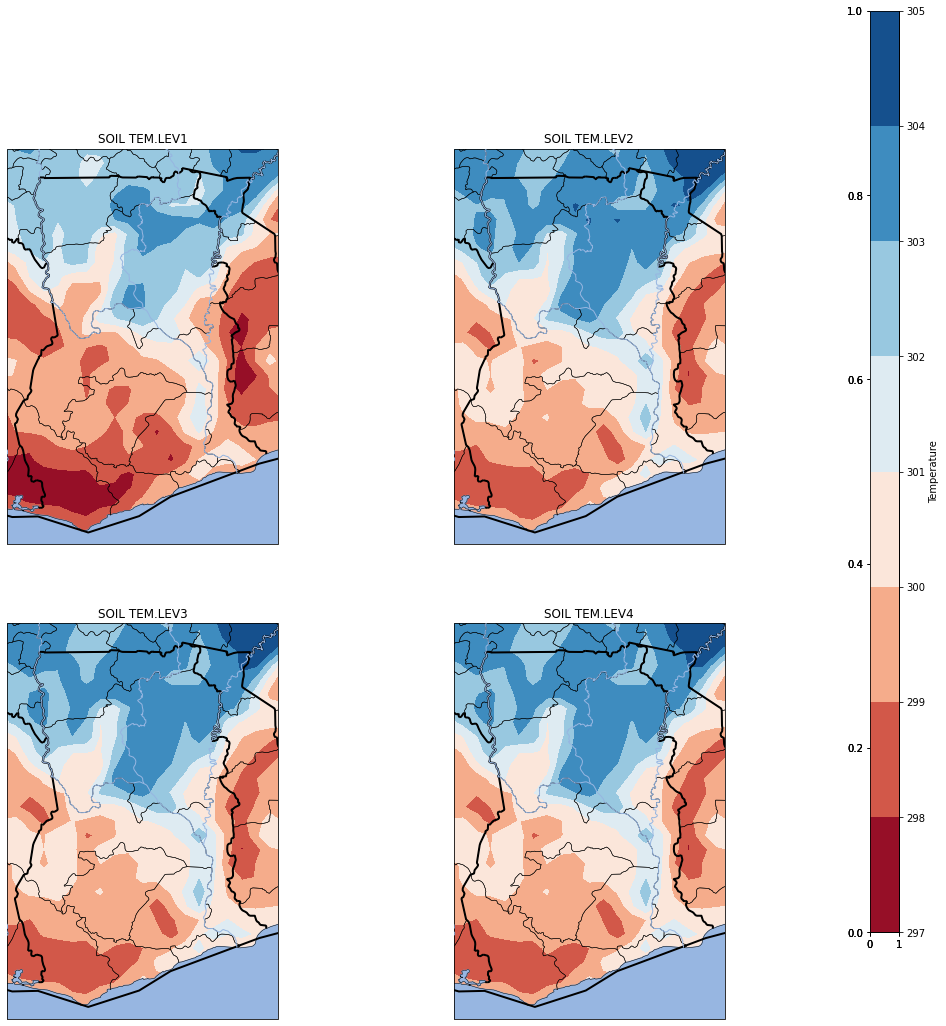

In [16]:



fig,ax=plt.subplots(2,2,  figsize=(16,16),subplot_kw={'projection':ccrs.PlateCarree()})
ax=ax.flatten()
for i in range(4):
    cb=ax[i].contourf(all_data[i].longitude, all_data[i].latitude, all_data[i],cmap='RdBu',transform=ccrs.PlateCarree())
    ax[i].add_feature(cfeature.COASTLINE.with_scale('110m'),linewidth=2,zorder=4)
    ax[i].add_feature(cfeature.BORDERS,linewidth=2, zorder=2)
    ax[i].add_feature(cfeature.STATES, linewidth=0.5, zorder=3)
    ax[i].add_feature(cfeature.OCEAN,zorder=1)
    ax[i].add_feature(cfeature.RIVERS,zorder=5)
    ax[i].set_extent([-3.4,1.4,4.5,11.5])
    ax[i].set_title(data_names[i])
    linewidths =5,
    s=100

    color_bar = fig.add_axes([0.95, 0.2, 0.025, 0.8])
#color_bar=fig.add_axes([0.95,0.38,0.053,0.33])
fig.colorbar(cb,cax=color_bar,label='Temperature')
#fig.subplots_adjust(wspace=-0.55, top=0.93)
    #fig.colorbar(cb,aspect=9)
plt.subplots_adjust(wspace=0.001)    